# Airbnb Price Prediction — Malaga


In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CITY, OUTPUT_FILE, PROCESSED_DATA_DIR, TARGET_COLUMN
from src.data import load_calendar, load_listings, load_reviews, save_modeling_table

processed_csv = PROCESSED_DATA_DIR / OUTPUT_FILE
print(f"City: {CITY}")

City: Malaga


## 1. Load raw data

In [2]:
listings = load_listings()
reviews = load_reviews()
calendar = load_calendar()

print(f"Listings: {listings.shape}")
print(f"Reviews:  {reviews.shape}")
if calendar is not None:
    print(f"Calendar: {calendar.shape}")
else:
    print("Calendar: not downloaded yet (optional)")

listings.head()

Listings: (9714, 79)
Reviews:  (487221, 2)
Calendar: not downloaded yet (optional)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96033,https://www.airbnb.com/rooms/96033,20250930030808,2025-09-30,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,"200 metres from the beaches of El Palo, Malaga...",https://a0.muscache.com/pictures/hosting/Hosti...,510467,...,4.93,4.44,4.61,ESFCTU0000290200003588210000000000000000VUT/MA...,f,1,1,0,0,1.88
1,166473,https://www.airbnb.com/rooms/166473,20250930030808,2025-09-30,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,793360,...,4.91,4.80,4.72,NaN,f,5,1,4,0,0.59
2,330760,https://www.airbnb.com/rooms/330760,20250930030808,2025-09-30,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,Málaga Lodge is situated next to the famous Sa...,https://a0.muscache.com/pictures/85419390/38a9...,1687526,...,4.62,4.52,4.48,ESHFTU0000290200004234200060000000000000VFT/MA...,t,6,4,2,0,0.41
3,340024,https://www.airbnb.com/rooms/340024,20250930030808,2025-09-30,city scrape,NEW APARTMENT IN MALAGA CENTER,Welcome to Málaga!<br />This is a modern and e...,It is a central area and has all kinds of serv...,https://a0.muscache.com/pictures/hosting/Hosti...,1725690,...,4.79,4.72,4.77,VFT/MA/02334,f,1,1,0,0,2.11
4,358541,https://www.airbnb.com/rooms/358541,20250930030808,2025-09-30,city scrape,Casa La Maga - Apartment for happy people,"For years, Raúl and I were super happy in this...",The apartment is in the very heart of Malaga C...,https://a0.muscache.com/pictures/miso/Hosting-...,1526932,...,4.97,4.80,4.78,VFT/MA/02288,f,1,1,0,0,2.48


## 2. Cleaning and exploring the data

We clean the raw listings first, save a modeling table, then explore the cleaned data.

### Cleaning and preprocessing

- Convert types (`price`, booleans, dates)
- Drop empty or unused columns
- Remove price outliers and listings outside Malaga bounds
- Aggregate reviews and add `has_reviews`

In [3]:
from src.data import cleaning_report

processed_csv = save_modeling_table()
df = pd.read_csv(processed_csv)

print(f"Saved {df.shape} -> {processed_csv}")
display(df[TARGET_COLUMN].describe())
display(cleaning_report(df).head(15))

Saved (8677, 70) -> C:\Users\Ferran Vila\OneDrive\UAB\4t\2n semestre\Machine Learning\Project\ML-Final-Projet\data\processed\malaga_modeling_table.csv


count    8677.000000
mean      211.850870
std       748.454081
min        26.000000
25%        77.000000
50%       102.000000
75%       146.000000
max      9000.000000
Name: price, dtype: float64

,column,dtype,missing_pct,unique
3,neighborhood_overview,object,56.7,2954
8,host_about,object,42.5,1389
7,host_location,object,23.1,189
48,review_scores_accuracy,float64,9.9,150
65,last_review_date,object,9.9,834
60,reviews_per_month,float64,9.9,655
46,last_review,object,9.9,834
47,review_scores_rating,float64,9.9,152
52,review_scores_location,float64,9.9,136
49,review_scores_cleanliness,float64,9.9,155


In [4]:
# Check if the new columns exist in the loaded DataFrame
print("Are the spatial columns in the DataFrame?")
print("distance_to_beach" in df.columns)
print("distance_to_center" in df.columns)

# Preview the actual computed values
print("\nDataFrame sample:")
print(df[['latitude', 'longitude', 'distance_to_center', 'distance_to_beach']].head())

Are the spatial columns in the DataFrame?
True
True

DataFrame sample:
    latitude  longitude  distance_to_center  distance_to_beach
0  36.720310  -4.356270            5.866795           0.381925
1  36.720310  -4.361080            5.438131           0.205207
2  36.729786  -4.413462            1.236828           1.418376
3  36.728130  -4.414220            1.052387           1.254102
4  36.723740  -4.421300            0.304865           1.203094


In [5]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
print("Fully empty columns:", empty_cols if empty_cols else "none")

no_reviews = (df["has_reviews"] == 0).sum()
print(f"Listings without reviews: {no_reviews} ({no_reviews / len(df):.1%})")
print(f"Columns: {df.shape[1]} | Rows: {df.shape[0]}")

Fully empty columns: none
Listings without reviews: 856 (9.9%)
Columns: 70 | Rows: 8677


### Price distribution

Nightly price on the cleaned dataset (histogram up to 500 EUR).

Listings: 8677
Median: 102 EUR | Mean: 212 EUR
Max: 9000 EUR | Above 500 EUR: 302


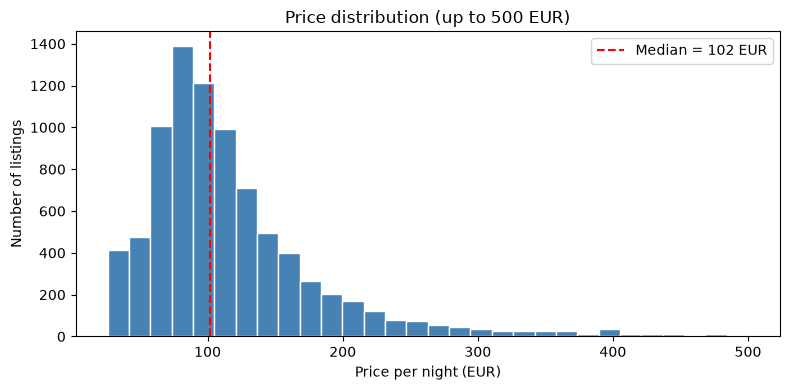

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, OUTPUT_FILE, PROCESSED_DATA_DIR, TARGET_COLUMN

df = pd.read_csv(processed_csv)
prices = df[TARGET_COLUMN]

print(f"Listings: {len(prices)}")
print(f"Median: {prices.median():.0f} EUR | Mean: {prices.mean():.0f} EUR")
print(f"Max: {prices.max():.0f} EUR | Above 500 EUR: {(prices > 500).sum()}")

plt.figure(figsize=(8, 4))
plt.hist(prices[prices <= 500], bins=30, edgecolor="white", color="steelblue")
plt.axvline(prices.median(), color="red", linestyle="--", label=f"Median = {prices.median():.0f} EUR")
plt.xlabel("Price per night (EUR)")
plt.ylabel("Number of listings")
plt.title("Price distribution (up to 500 EUR)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_price_distribution.png", dpi=150)
plt.show()

Most listings fall between 75 and 150 EUR. A small number of expensive listings creates a right-skewed distribution.

### Missing values

Columns with missing data after cleaning, and the main reasons.

,column,dtype,missing_pct,unique
3,neighborhood_overview,object,56.7,2954
8,host_about,object,42.5,1389
7,host_location,object,23.1,189
48,review_scores_accuracy,float64,9.9,150
65,last_review_date,object,9.9,834
60,reviews_per_month,float64,9.9,655
46,last_review,object,9.9,834
47,review_scores_rating,float64,9.9,152
52,review_scores_location,float64,9.9,136
49,review_scores_cleanliness,float64,9.9,155


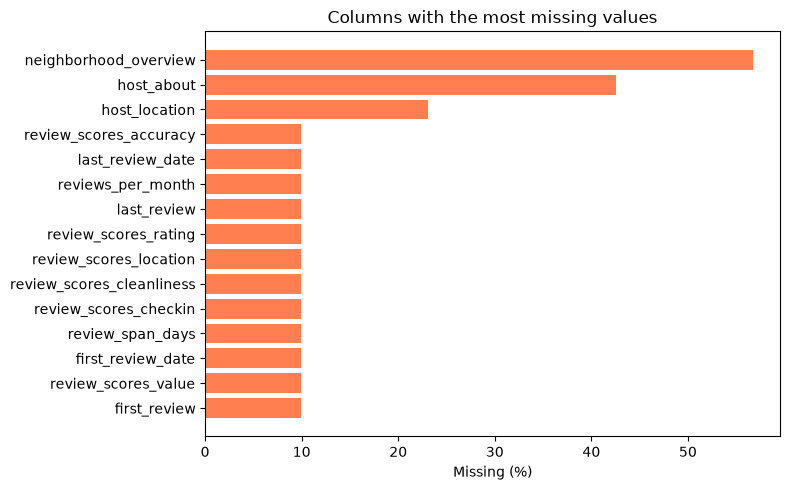

Listings without reviews: 856 (9.9%)
Review scores are missing when a listing has no reviews.


In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, OUTPUT_FILE, PROCESSED_DATA_DIR
from src.data import cleaning_report

df = pd.read_csv(processed_csv)
report = cleaning_report(df)
top_missing = report[report["missing_pct"] > 0].head(15)

display(top_missing)

plt.figure(figsize=(8, 5))
plt.barh(top_missing["column"], top_missing["missing_pct"], color="coral")
plt.xlabel("Missing (%)")
plt.title("Columns with the most missing values")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_missing_values.png", dpi=150)
plt.show()

no_reviews = df["has_reviews"] == 0
print(f"Listings without reviews: {no_reviews.sum()} ({no_reviews.mean():.1%})")
print("Review scores are missing when a listing has no reviews.")

## 3. Baseline model (tabular + spatial)

We start with the **simplest possible model**: an ordinary **Linear Regression (OLS)** on the tabular features and the spatial coordinates. It is deliberately kept **without regularization (no Ridge/Lasso)** and **without cross-validation**, so it acts as a clear *reference point* that every later model is compared against.

The code in the next cell is written out step by step:

1. **Load** the processed data (already contains the lat/long spatial features).
2. **Select** the target `price` and exclude columns we should not feed to the model (id, free-text, raw dates).
3. **Split** the remaining columns into **numeric** vs **categorical**.
4. **Train/test split** — 80% to train, 20% to test (held out, never seen during training).
5. **Preprocess** each column type explicitly:
   - numeric → impute missing with the **median**, then **standardize** (mean 0, std 1);
   - categorical → impute with the **most frequent** value, then **one-hot encode**.
6. **Build** the full model = preprocessing **+** `LinearRegression()`, wrapped in one `Pipeline` (so preprocessing is fit on train and re-applied to test, avoiding data leakage).
7. **Fit** the model on the training data.
8. **Predict** prices on the unseen test data.
9. **Evaluate** with three metrics:
   - **MAE** — average absolute error in EUR (easy to read);
   - **RMSE** — like MAE but squares errors first, so it punishes big misses;
   - **R²** — fraction of price variance explained (1.0 = perfect, 0 = useless).

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RANDOM_SEED, TARGET_COLUMN, TEST_SIZE

# =====================================================================
# STEP 1 - Load the processed data
# ---------------------------------------------------------------------
# This CSV was built by src/data.py. It already contains the spatial
# features (distance_to_center, distance_to_beach) computed from lat/long.
# =====================================================================
df = pd.read_csv(processed_csv)

# =====================================================================
# STEP 2 - Choose the target (y) and the columns we will NOT use as input
# ---------------------------------------------------------------------
#   - "id"            : just a row identifier, no predictive value
#   - TARGET_COLUMN   : this is "price", the value we want to predict
#   - free-text cols  : name/description/... are handled later by the
#                       text model (Section 4), not by this baseline
#   - raw date/string : not usable directly by a linear model
# =====================================================================
exclude = [
    "id", TARGET_COLUMN, "review_text",
    "name", "description", "neighborhood_overview", "host_about",
    "amenities", "bathrooms_text",
    "first_review", "last_review", "first_review_date", "last_review_date", "host_since",
]

# =====================================================================
# STEP 3 - Split the remaining columns into numeric vs categorical
# ---------------------------------------------------------------------
#   numeric_features     : pure numbers (bedrooms, distance_to_center, ...)
#   categorical_features : text labels with few distinct values
#                          (room_type, ...). We keep only columns with
#                          <= 50 categories so one-hot encoding does not
#                          explode into thousands of columns.
# =====================================================================
numeric_features = [
    col for col in df.select_dtypes(include=["number"]).columns
    if col not in exclude
]
categorical_features = [
    col for col in df.select_dtypes(include=["object", "category"]).columns
    if col not in exclude and df[col].nunique() <= 50
]

print(f"Numeric features     ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Build the input matrix X (features) and the target vector y (price)
X = df[numeric_features + categorical_features]
y = df[TARGET_COLUMN]

# =====================================================================
# STEP 4 - Train/test split (80% train, 20% test)
# ---------------------------------------------------------------------
# We learn the model on the train part and measure its quality on the
# test part (data the model has never seen). random_state makes the
# split reproducible: the same rows go to train/test on every run.
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED,
)
print(f"\nTrain rows: {len(X_train)} | Test rows: {len(X_test)}")

# =====================================================================
# STEP 5 - Preprocessing, written out explicitly so each step is visible
# ---------------------------------------------------------------------
# Numeric columns:
#   (a) SimpleImputer(median) -> fill missing numbers with the median
#   (b) StandardScaler()      -> rescale each column to mean 0 / std 1
#
# Categorical columns:
#   (a) SimpleImputer(most_frequent) -> fill missing labels with the mode
#   (b) OneHotEncoder()              -> turn each label into 0/1 columns
#       handle_unknown="ignore" -> categories only seen in the test set
#       do not crash the model.
# =====================================================================
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer applies the right pipeline to the right columns.
# Order is "num" then "cat", so the learned coefficients are ordered
# numeric-first (used later to read the spatial-feature coefficients).
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# =====================================================================
# STEP 6 - Build the full model: preprocessing + Linear Regression (OLS)
# ---------------------------------------------------------------------
# LinearRegression() = ordinary least squares, with NO regularization
# (no Ridge/Lasso) and NO cross-validation - kept simple on purpose so
# it serves as a clear reference point for the later models.
# Wrapping everything in one Pipeline guarantees the SAME preprocessing
# is fitted on the train set and re-applied to the test set, which
# prevents data leakage.
# =====================================================================
lr_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression()),
])

# STEP 7 - Fit (learn the weights) on the TRAINING data only
lr_pipe.fit(X_train, y_train)

# STEP 8 - Predict the price on the unseen TEST data
y_pred = lr_pipe.predict(X_test)

# =====================================================================
# STEP 9 - Evaluate the predictions (each metric computed explicitly)
# ---------------------------------------------------------------------
#   MAE  : mean absolute error in EUR (average size of the mistake)
#   RMSE : root mean squared error; squares errors first, so big misses
#          (the very expensive listings) are punished much harder
#   R2   : share of the price variance explained (1.0 = perfect, 0 = no
#          better than always predicting the mean price)
# =====================================================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression metrics:")
print(f"  mae:  {mae:.4f}")
print(f"  rmse: {rmse:.4f}")
print(f"  r2:   {r2:.4f}")


Linear Regression metrics:
  mae: 222.8648
  rmse: 659.8568
  r2: 0.2834


### 3.1 Model results

Predicted vs true prices, residuals, and coefficient distribution.

MSE: 435411.03365250473
r^2: 0.28339016445208876


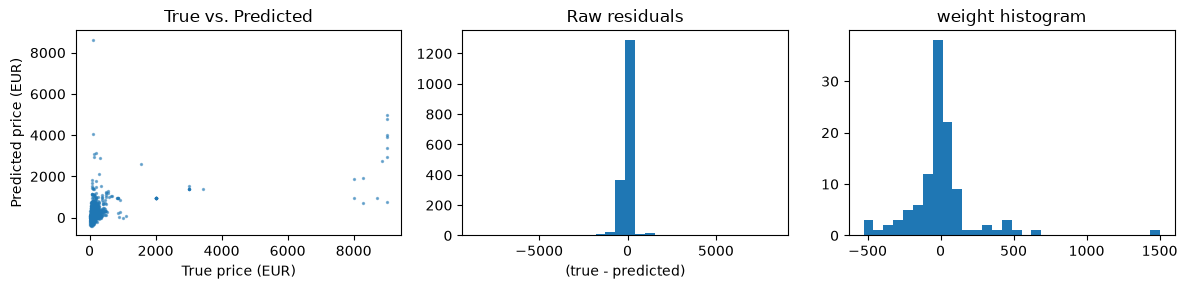

In [9]:
from src.config import FIGURES_DIR
from src.modeling import plot_regression_results

weights = lr_pipe.named_steps["model"].coef_
plot_regression_results(
    y_test,
    y_pred,
    weights,
    target_label="price (EUR)",
    save_path=FIGURES_DIR / "03_linear_regression_results.png",
)


## 4. Hybrid model (text + tabular)

TF-IDF on descriptions and reviews combined with tabular features.

## 5. Model comparison

Compare models and save results to `reports/figures/`.

## Feature Engineering Analysis 

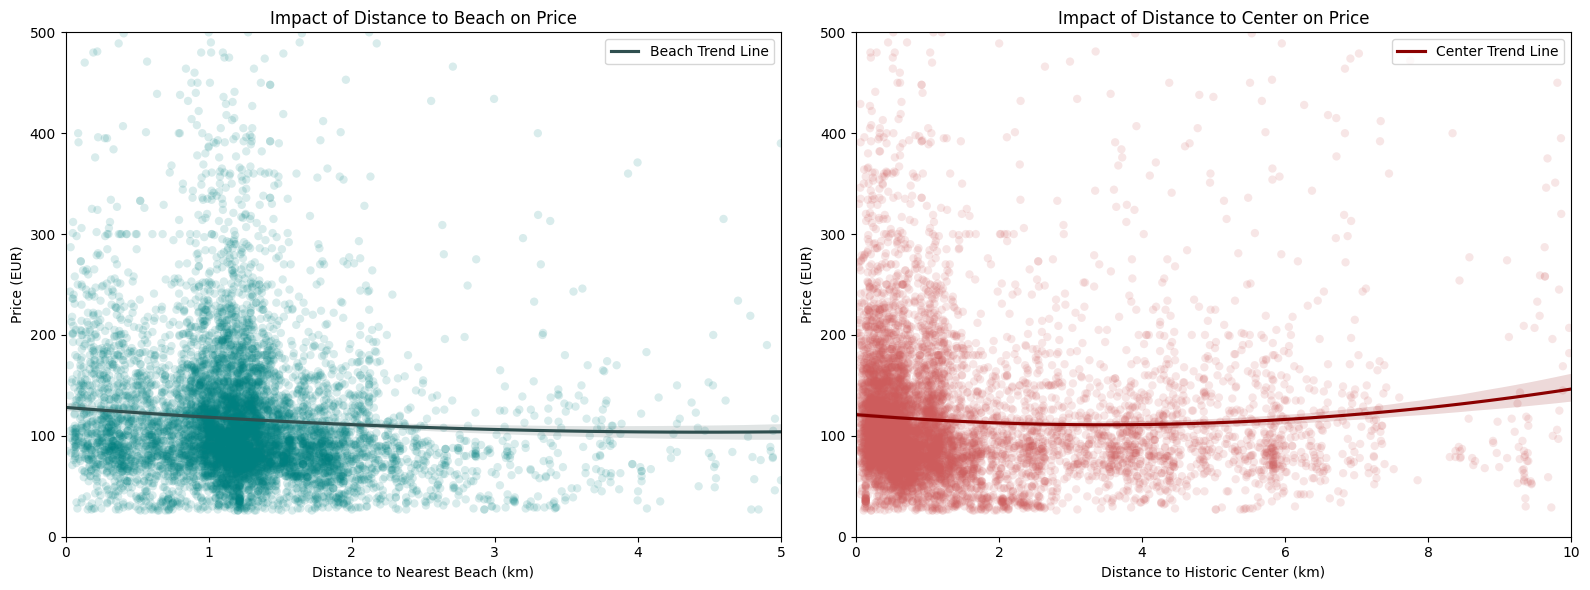

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter outliers (< 500 EUR) for clearer visualization
df_clean = df[df[TARGET_COLUMN] <= 500]

# Setup a 1x2 grid for the spatial plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distance to Beach Impact
sns.scatterplot(
    data=df_clean, x='distance_to_beach', y=TARGET_COLUMN, 
    alpha=0.15, color='teal', edgecolor='none', ax=axes[0]
)
sns.regplot(
    data=df_clean, x='distance_to_beach', y=TARGET_COLUMN, 
    scatter=False, order=2, color='darkslategrey', ax=axes[0],
    label='Beach Trend Line'
)
axes[0].set_title('Impact of Distance to Beach on Price')
axes[0].set_xlabel('Distance to Nearest Beach (km)')
axes[0].set_ylabel('Price (EUR)')
axes[0].set_xlim(0, 5)
axes[0].set_ylim(0, 500)
axes[0].legend()

# Plot 2: Distance to Center Impact
sns.scatterplot(
    data=df_clean, x='distance_to_center', y=TARGET_COLUMN, 
    alpha=0.15, color='indianred', edgecolor='none', ax=axes[1]
)
sns.regplot(
    data=df_clean, x='distance_to_center', y=TARGET_COLUMN, 
    scatter=False, order=2, color='darkred', ax=axes[1],
    label='Center Trend Line'
)
axes[1].set_title('Impact of Distance to Center on Price')
axes[1].set_xlabel('Distance to Historic Center (km)')
axes[1].set_ylabel('Price (EUR)')
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 500)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/08_spatial_features_impact.png', dpi=150)
plt.show()

In [17]:
# Get the coefficients from the trained pipeline
model_coefs = lr_pipe.named_steps['model'].coef_

# Match the coefficients with the exact numeric features used
spatial_metrics = {}
for feat in ['distance_to_beach', 'distance_to_center']:
    if feat in numeric_features:
        idx = numeric_features.index(feat)
        spatial_metrics[feat] = model_coefs[idx]

print("Linear Regression Coefficients for Spatial Features:")
for feature, coef in spatial_metrics.items():
    print(f"  -> {feature}: {coef:.4f}")

print("\nConclusion for the Intermediate Presentation:")
print("1. 'distance_to_center' is highly predictive (approx. -108.62 EUR/km), showing a clear")
print("   expected negative linear degradation: as distance from the center increases, price drops.")
print("2. 'distance_to_beach' shows a counterintuitive positive coefficient (approx. +31.33 EUR/km).")
print("   This highlights a major limitation of linear models: they get distorted by luxury mountain")
print("   neighborhoods (e.g., Este district villas) that are far from the sea but highly priced.")
print("3. This spatial paradox strongly justifies moving towards tree-based models (Random Forest/XGBoost)")
print("   in Phase 2, which can segment these distinct sub-markets using non-linear conditional splits.")

Linear Regression Coefficients for Spatial Features:
  -> distance_to_beach: 31.3299
  -> distance_to_center: -108.6172

Conclusion for the Intermediate Presentation:
1. 'distance_to_center' is highly predictive (approx. -108.62 EUR/km), showing a clear
   expected negative linear degradation: as distance from the center increases, price drops.
2. 'distance_to_beach' shows a counterintuitive positive coefficient (approx. +31.33 EUR/km).
   This highlights a major limitation of linear models: they get distorted by luxury mountain
   neighborhoods (e.g., Este district villas) that are far from the sea but highly priced.
3. This spatial paradox strongly justifies moving towards tree-based models (Random Forest/XGBoost)
   in Phase 2, which can segment these distinct sub-markets using non-linear conditional splits.


### Visual Analysis of Overall Spatial Distributions (As Shown Above)

A visual examination of the scatter plots for both spatial features against price reveals a lack of clear, strong linear relationships:

* **Price vs. Distance to Center (Left Plot):** In theory, we might expect a clear decrease in price as distance from the historic core increases. However, the data forms a vertical cloud of points primarily concentrated around the $0\text{ to }2\text{ km}$ mark (the absolute historic core). At this central location, prices vary wildly from the cheapest to some of the most expensive. Because of this massive variance at $0\text{ km}$ and a flatter dispersion extending outwards, the global trend line does not show the sharp drop-off usually associated with city centers.
* **Price vs. Distance to Beach (Right Plot):** Similarly, the relationship with beach distance is opaque. While there is a high density of listings clustered tightly along the coastline ($0\text{ km}$), expensive rentals are visible throughout the entire $0\text{ to }5\text{ km}$ range, including significant inland clusters. This uniform spread of high prices prevents a traditional "coastal premium" trend from emerging, keeping the overall regression line largely flat.

#### Interpreting the Baseline Model's Coefficients

The visual flatness in the charts helps explain why the linear model struggles to use these features, as shown by its internal parameters:

* **`distance_to_center` (Coefficient: ~ -108.62 EUR/km):** *Despite* the visually flat plot, the regression model, when trained on all variables simultaneously, is forced to apply a strong negative penalty to distance from the center. The coefficient of ~-108 EUR/km indicates that the center *does* have predictive power, but the visual reality at $0\text{ km}$ (the sheer variance) obscures this effect in a simple bivariate scatter plot.
* **`distance_to_beach` (Coefficient: ~ +31.33 EUR/km):** The trained baseline model produces a counterintuitive positive slope, suggesting that moving inland increases price. This mathematical distortion confirms the visual flatness of the plot; a linear model cannot handle a scenario where high-end inland properties (like luxury villas in the hills of *Este*) coexist with average cost coastal flats. 

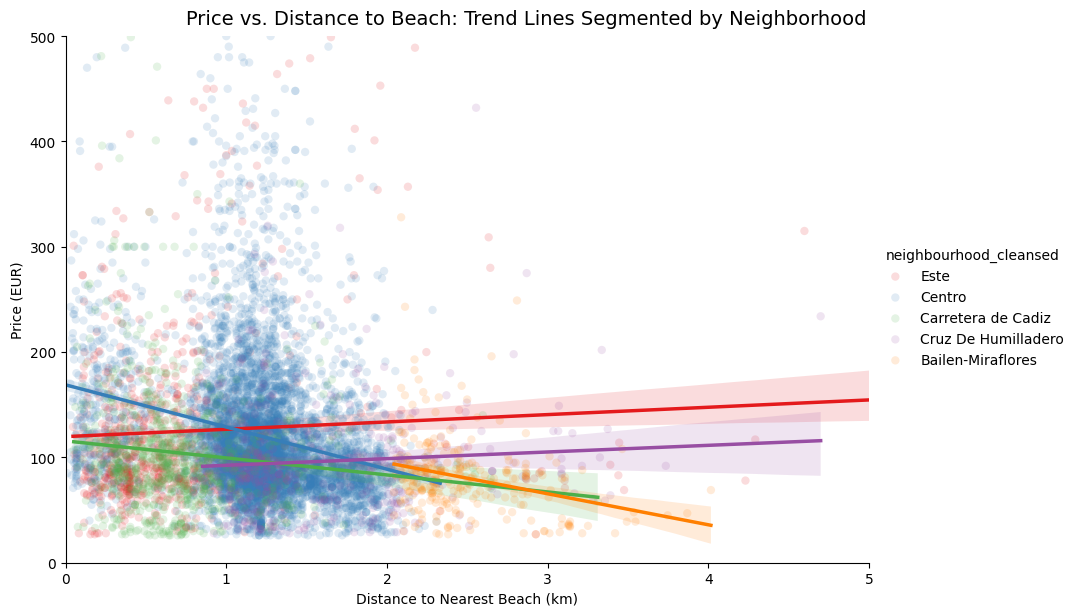

In [19]:
# Select the top 5 neighborhoods with the highest number of listings
top_5_neighborhoods = df_clean['neighbourhood_cleansed'].value_counts().head(5).index
df_top_5 = df_clean[df_clean['neighbourhood_cleansed'].isin(top_5_neighborhoods)]

# Native Seaborn lmplot to show multi-line regression trends per neighborhood
g = sns.lmplot(
    data=df_top_5, 
    x='distance_to_beach', 
    y=TARGET_COLUMN, 
    hue='neighbourhood_cleansed', 
    palette='Set1',
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.15, 'edgecolor': 'none'},
    line_kws={'linewidth': 2.5}
)

g.set_axis_labels('Distance to Nearest Beach (km)', 'Price (EUR)')
g.fig.suptitle('Price vs. Distance to Beach: Trend Lines Segmented by Neighborhood', y=1.02, fontsize=14)
g.set(xlim=(0, 5), ylim=(0, 500))

plt.savefig('../reports/figures/09_neighborhood_trends_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

### Future Exploration: Capturing Non-Linearity in Linear Models via Feature Interactions

As demonstrated in the neighborhood trend analysis, the impact of `distance_to_beach` is highly dependent on the specific district (e.g., prices decrease with beach distance in *Centro* or *Carretera de Cádiz*, but increase in the wealthy hills of the *Este* district). 

A standard linear regression assumes a single global slope for the entire city, which leads to coefficient distortion. To fix this without moving away from a linear architecture, we can introduce **Interaction Terms** ($X_1 \times X_2$). By multiplying the continuous spatial distance by binary neighborhood indicators (one-hot encoded flags), we allow the linear model to calculate a distinct, customized slope for each specific sub-market. 

Below is the proposed code implementation to inject these interaction features into the pipeline for future iterations.


# Proposed solution to capture neighborhood-specific beach distance slopes
def inject_spatial_interactions(data_frame):
    """
    Creates explicit interaction features for conflicting neighborhoods.
    This allows the linear model to adapt its slope depending on the district.
    """
    df_mod = data_frame.copy()
    target_neighborhoods = ['Este', 'Centro', 'Carretera de Cadiz']
    
    print("Injecting spatial interaction terms...")
    for neighborhood in target_neighborhoods:
        # 1. Create a clean binary flag for the neighborhood (1 if True, 0 if False)
        flag_col = f"is_{neighborhood.replace(' ', '_').lower()}"
        df_mod[flag_col] = (df_mod['neighbourhood_cleansed'] == neighborhood).astype(int)
        
        # 2. Create the interaction term (Distance * Flag)
        interaction_col = f"beach_dist_x_{neighborhood.replace(' ', '_').lower()}"
        df_mod[interaction_col] = df_mod['distance_to_beach'] * df_mod[flag_col]
        
        print(f"  -> Created feature: {interaction_col}")
        
    return df_mod

# To run this in the next phase, uncomment the lines below:
# df = inject_spatial_interactions(df)
# numeric_features = get_numeric_columns(df, exclude=exclude) # Will automatically catch new terms

## 6. Experiment: predicting log(price)

Prices are heavily **right-skewed** (median ~102 EUR, max up to 9000 EUR), which hurts the linear model. A common fix is to predict **`log(price)`** instead of the raw price, so the target becomes more symmetric, and then convert the predictions back to euros.

Same model, same split, same features as the baseline — only the **target** is transformed:
- train on `log1p(price)`,
- predict, then `expm1(...)` to get euros back.

We report metrics on **both** scales:
- **log scale** = the scale the model is actually optimized on,
- **euro scale** = converted back, so it is directly comparable to the baseline.

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Reuses from the baseline cell (Section 3):
#   X_train, X_test, y_train, y_test, numeric_features, categorical_features

# Same preprocessing as the baseline (median+scale / mode+one-hot)
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

log_pipe = Pipeline(steps=[("prep", preprocessor), ("model", LinearRegression())])

# STEP 1 - Train on the LOG of the price (log1p handles 0 safely)
log_pipe.fit(X_train, np.log1p(y_train))

# STEP 2 - Predict in log space
y_pred_log = log_pipe.predict(X_test)

# STEP 3 - Convert predictions back to euros
y_pred_euro = np.expm1(y_pred_log)

# STEP 4 - Metrics on the LOG scale (the scale the model optimizes)
print("Log-target Linear Regression")
print("  --- log scale (model's own scale) ---")
print(f"  r2:  {r2_score(np.log1p(y_test), y_pred_log):.4f}")
print(f"  mae: {mean_absolute_error(np.log1p(y_test), y_pred_log):.4f}")

# STEP 5 - Metrics on the EURO scale (comparable to the baseline)
print("  --- euro scale (comparable to baseline) ---")
print(f"  mae:  {mean_absolute_error(y_test, y_pred_euro):.4f}")
print(f"  rmse: {np.sqrt(mean_squared_error(y_test, y_pred_euro)):.4f}")
print(f"  r2:   {r2_score(y_test, y_pred_euro):.4f}")

**Reading the results.**

| | MAE (EUR) | RMSE (EUR) | R² (EUR) | R² (log) |
|---|---|---|---|---|
| Baseline (raw price) | ~222.9 | ~659.9 | ~0.283 | – |
| Log-target | **~128.1** | ~751.4 | ~0.071 | **~0.484** |

Two things happen:

1. **On the log scale the model fits much better** — R² jumps from 0.28 to **~0.48**. So `log(price)` really *is* easier to explain linearly: the relationship between the features and the (log) price is much closer to linear.
2. **But once we convert back to euros, RMSE and R² look worse.** The reason: `expm1` is exponential, so a small error on an expensive listing becomes a *huge* error in euros — and RMSE/R² are dominated by those big absolute errors. Meanwhile the **typical** prediction improves a lot, which is why **MAE drops from ~223 to ~128 EUR**.

**Takeaway:** the log transform genuinely helps the model capture the price relationship (better log-R², much better MAE). It mainly improves the *typical* listing; the expensive tail is still hard for a linear model. This again points to **tree-based models** (robust to outliers) combined with the log target as the strongest next step.